### Linear regression: calculate brain weight based on head size
1. Load data (X,Y): 40 number of data points
2. Get data matrix
3. Find w as derived
4. Predict labels

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('brain_dataset.csv')
df.head()

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [27]:
X = df['Head Size(cm^3)'].values.reshape(-1, 1)
y = df['Brain Weight(grams)'].values.reshape(-1, 1)
n = X.shape[0]
X_design = np.hstack([np.ones((n, 1)), X])

XtX = X_design.T @ X_design
XtX_inv = np.linalg.inv(XtX)
w = XtX_inv @ X_design.T @ y
w = w.flatten()  # [intercept, slope]
print('Weights (intercept, slope):', w)

Weights (intercept, slope): [3.25573421e+02 2.63429339e-01]


MSE: 5201.3840, R^2: 0.6393


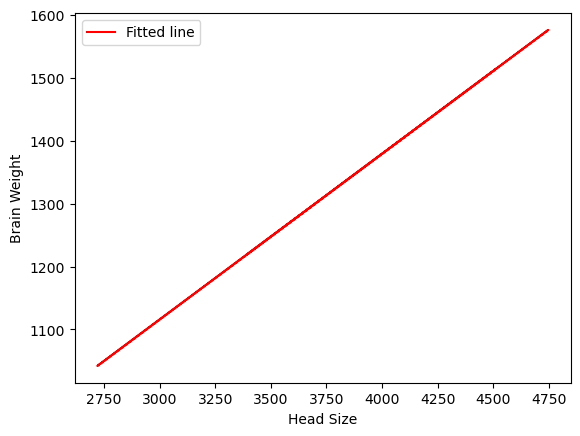

In [30]:
y_pred = X_design @ w.reshape(-1, 1)
mse = np.mean((y - y_pred) ** 2)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
print(f'MSE: {mse:.4f}, R^2: {r2:.4f}')

plt.plot(X[:, 0], y_pred[:, 0], color='red', label='Fitted line')
plt.xlabel('Head Size')
plt.ylabel('Brain Weight')
plt.legend()
plt.show()